### Conditional Workflow

Here we are creating conditional workflow using LangGraph

### Problem Statement

Build a **conditional workflow using LangGraph in Python** that processes a customer support query.

The workflow should:

1. Receive a customer query.
2. Determine whether the query is related to **billing**, **technical support**, or **general information**.
3. Based on the classification, route the query to the appropriate processing node.
4. Generate a suitable response for the customer.
5. End the workflow after returning the response.


In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

In [3]:
load_dotenv()

True

In [4]:
model = ChatOpenAI(model='gpt-5.4-mini', max_completion_tokens=300)
model

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.14', 'langchain-openai': '1.3.5'}}, output_version=None, profile={'name': 'GPT-5.4 mini', 'release_date': '2026-03-17', 'last_updated': '2026-03-17', 'open_weights': False, 'max_input_tokens': 400000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000210513D56A0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000210513D6120>, root_client=<openai.OpenAI objec

In [7]:
# Query category pydantic class
class QueryCategorySchema(BaseModel):
    category: Literal['billing', 'technical support', 'general information'] = Field(description="This field is about the category of the customer query into billing, technical support and general information.")

In [8]:
# category model
category_model = model.with_structured_output(QueryCategorySchema)

In [9]:
class CustomerQueryState(TypedDict):
    query: str
    category: Literal['billing', 'technical support', 'general information']
    response: str

In [21]:
def categorize_query(state: CustomerQueryState) -> CustomerQueryState:
    query = state['query']
    category = category_model.invoke(f"Categorize the customer query: {query}")
    return {'category': category}

In [22]:
def billing_response(state: CustomerQueryState) -> CustomerQueryState:
    query = state['query']

    response = model.invoke(f"Give the suitable response to the customer having query: {query} related to billing.").content

    return {'response': response}

In [23]:
def technical_support_response(state: CustomerQueryState) -> CustomerQueryState:
    query = state['query']

    response = model.invoke(f"Give the suitable response to the customer having query: {query} related to technical support.").content

    return {'response': response}

In [24]:
def general_information_response(state: CustomerQueryState) -> CustomerQueryState:
    query = state['query']

    response = model.invoke(f"Give the suitable response to the customer having query: {query} related to general information.").content

    return {'response': response}

In [37]:
def final_response(state: CustomerQueryState) -> CustomerQueryState:
    print(f"query: {state['query']}\n")
    print(f"category: {state['category']}\n")
    print(f"response: {state['response']}\n")
    return state

In [38]:
# Condition for the workflow, checks the category and call the respective function
def category_condition(state: CustomerQueryState) -> Literal['billing_response', 'general_information_response', 'technical_support_response']:
    category = state['category']
    if category == 'billing':
        return 'billing_response'
    elif category == 'technical support':
        return 'technical_support_response'
    else:
        return 'general_information_response'

In [39]:
# Graph
graph = StateGraph(CustomerQueryState)

In [40]:
# Graph Nodes
graph.add_node('categorize_query', categorize_query)
graph.add_node('billing_response', billing_response)
graph.add_node('technical_support_response', technical_support_response)
graph.add_node('general_information_response', general_information_response)
graph.add_node('final_response', final_response)


# Graph Edges
graph.add_edge(START, 'categorize_query')
graph.add_conditional_edges('categorize_query', category_condition)
graph.add_edge('billing_response', 'final_response')
graph.add_edge('technical_support_response', 'final_response')
graph.add_edge('general_information_response', 'final_response')
graph.add_edge('final_response', END)

# Graph compile
workflow = graph.compile()

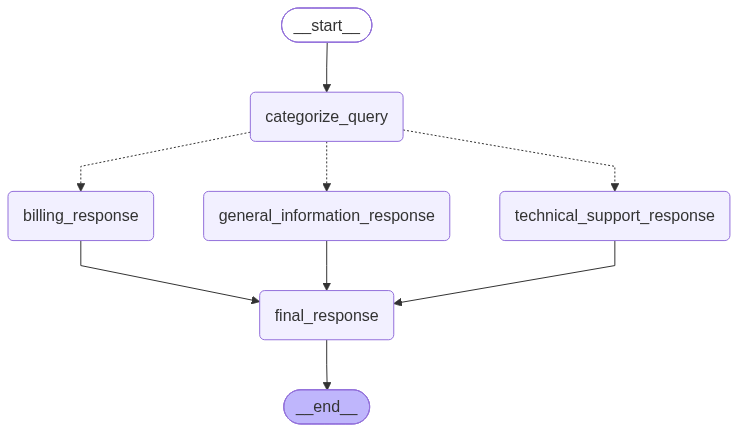

In [41]:
workflow

In [42]:
initial_state = {'query': "I was charged twice for my subscription this month. Can you help me get a refund for the duplicate payment?"}
res = workflow.invoke(initial_state)

query: I was charged twice for my subscription this month. Can you help me get a refund for the duplicate payment?

category: category='billing'

response: I’m sorry for the inconvenience. Yes, I can help with that.

Please share the following details so we can review the duplicate charge and check refund eligibility:
- The email address associated with your account
- The date(s) and amount(s) of the charges
- A screenshot or receipt showing the duplicate payment, if available
- The last 4 digits of the card or the payment method used

Once we have that information, we can investigate the subscription billing and guide you through the refund process.



In [43]:
initial_state = {'query': "The application keeps crashing whenever I try to upload a file. How can I fix this issue?"}
res = workflow.invoke(initial_state)

query: The application keeps crashing whenever I try to upload a file. How can I fix this issue?

category: category='technical support'

response: I’m sorry you’re experiencing this. Here are a few general steps that often help when an app crashes during file upload:

1. **Check the file type and size**  
   Make sure the file is supported by the app and doesn’t exceed the maximum upload size.

2. **Try a different file**  
   Upload another file to see if the issue is specific to one file.

3. **Restart the app or device**  
   Close the application completely and reopen it. If needed, restart your device.

4. **Update the app**  
   Ensure you’re using the latest version, as updates often fix stability issues.

5. **Clear cache or temporary data**  
   If the app has a cache-clear option, try clearing it and then upload again.

6. **Check your internet connection**  
   A weak or unstable connection can sometimes cause crashes during uploads.

7. **Free up device memory/storage**  


In [44]:
initial_state = {'query': "What are the available subscription plans and what features are included in each plan?"}
res = workflow.invoke(initial_state)

query: What are the available subscription plans and what features are included in each plan?

category: category='general information'

response: Here’s a suitable response:

We offer a range of subscription plans to fit different needs. The exact plans and included features may vary depending on the product or service you’re using. Typically, plans may include:

- **Basic/Starter plan**: Core features for individuals or small teams
- **Standard/Pro plan**: Additional tools, more usage limits, and enhanced support
- **Premium/Enterprise plan**: Full feature access, advanced capabilities, and priority or dedicated support

If you’d like, I can provide the detailed plan comparison for your specific product or help you choose the best option based on your needs.

